# Diabetes Prediction | Logistic Regression

An end-to-end binary classification workflow covering data analysis, Logistic Regression modeling, model evaluation, hyperparameter tuning, and threshold optimization.

## 1. Project Overview

This project develops a classification workflow to predict diabetes outcomes using Logistic Regression.

The focus is not only on model performance, but also on understanding the dataset, validating data quality, exploring relationships between features, preparing the data correctly, evaluating the model, and interpreting the results.


## 2. Problem Statement

Diabetes prediction is a binary classification problem.

The objective is to predict whether a patient is likely to have diabetes based on diagnostic measurements.

Key questions:
- Which features show stronger relationships with diabetes outcome?
- How should the data be prepared before modeling?
- How well does Logistic Regression classify unseen cases?
- Which evaluation metrics provide a better understanding of model performance?


## 3. Dataset and Feature Dictionary

The dataset contains medical diagnostic measurements.

Features:
- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

Target:
- Outcome (0 = No Diabetes, 1 = Diabetes)


## 4. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve )

import warnings
warnings.filterwarnings("ignore")

sns.set_style("white")

# Shared portfolio palette
PRIMARY = "#4C72B0"      # blue
SECONDARY = "#55A868"    # green
ACCENT = "#C44E52"       # reserved for warnings / emphasis
NEUTRAL = "#7F7F7F"      # gray

correlation_cmap = LinearSegmentedColormap.from_list( "portfolio_blue_green", [PRIMARY, "#F2F2F2", SECONDARY] )

## 5. Load the Dataset

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Dataset Loading Insight

The dataset has been successfully loaded and the first rows provide an initial view of the available features and target variable. This step helps confirm that the structure of the data matches the expected classification problem.

## 6. Initial Data Validation

Checking dataset structure, missing values, duplicates, and invalid values before modeling.


In [3]:
df.shape

(768, 9)

### Dataset Size Insight

The dataset size gives an initial understanding of the number of observations available for model training and evaluation. A sufficient number of samples is important for building a reliable baseline model.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Statistical Summary Insight

The descriptive statistics help identify feature ranges, possible outliers, and differences in scale between variables. These observations guide the preprocessing decisions before modeling.

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Missing Values Insight

This check confirms whether missing values exist in the dataset. Identifying data quality issues before modeling helps prevent unreliable predictions.

In [7]:
df.duplicated().sum()

0

### Duplicate Records Insight

Checking duplicate rows ensures that repeated observations do not unintentionally influence the training process.

### Data-quality notes

Some medical variables should not normally contain zero values. These cases should be reviewed before training the model.


In [8]:
zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

(df[zero_columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

### Data Quality Insight

Some medical measurements contain zero values that may not represent realistic observations. These values require review before model training to improve data reliability.

## 7. Feature Engineering: Clinical Data Preparation

In [9]:
df_clean = df.copy()

zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 8. Exploratory Data Analysis

Understanding distributions and relationships between variables before modeling.


### Target Distribution

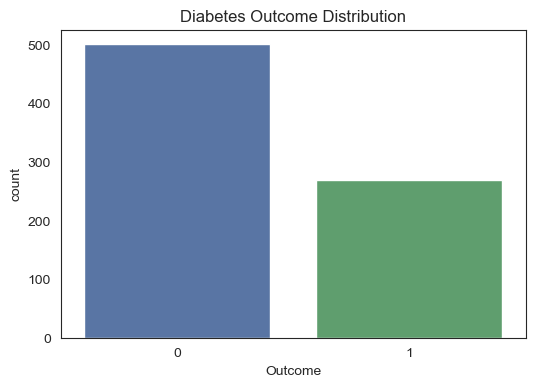

In [10]:
plt.figure(figsize=(6,4))
sns.countplot( data=df_clean, x="Outcome", palette={ 0: PRIMARY, 1: SECONDARY } )
plt.title("Diabetes Outcome Distribution")
plt.show()

### Target Distribution Insight

The target distribution shows the balance between diabetic and non-diabetic cases. The difference between the two classes should be considered when selecting evaluation metrics and interpreting model performance.

### Numeric Relationships

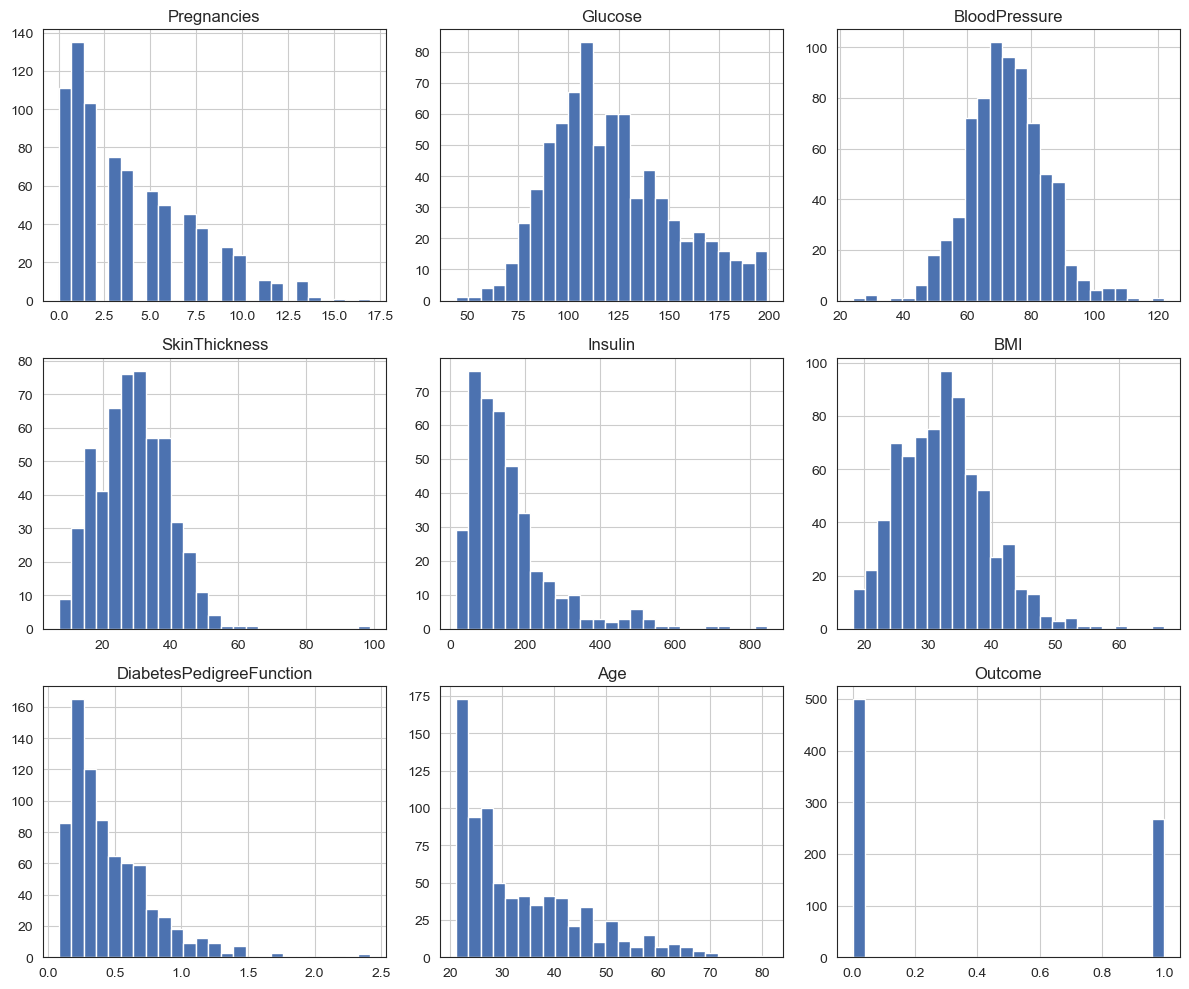

In [11]:
df_clean.hist(figsize=(12,10), bins=25, color=PRIMARY)
plt.tight_layout()
plt.show()

### Feature Distribution Insight

The feature distributions provide an overview of data patterns, ranges, and potential skewness. Understanding these characteristics helps determine appropriate preprocessing steps.

### Correlation Analysis

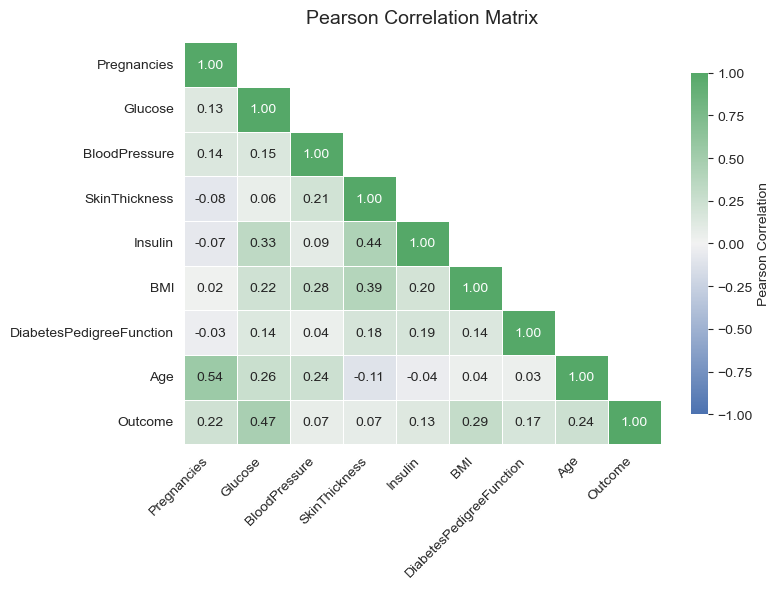

In [12]:
target = "Outcome"

# Pearson correlation is calculated only for numerical variables.
numeric_df = df.select_dtypes(include="number")

# Keep the target as the last column for easier visual interpretation.
df_ordered = pd.concat( [numeric_df.drop(columns=target), numeric_df[[target]]], axis=1 )

# Pearson correlation is used because this project focuses
# on linear relationships.
corr_matrix = df_ordered.corr(method="pearson")

# Mask the upper triangle to avoid showing duplicate information.
mask = np.triu( np.ones_like(corr_matrix, dtype=bool), k=1 )

plt.figure(figsize=(8, 6), dpi=100)

sns.heatmap( corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=correlation_cmap, center=0, vmin=-1, vmax=1,
             linewidths=0.5, linecolor="white", square=False, annot_kws={"size": 10},
             cbar_kws={ "shrink": 0.85, "label": "Pearson Correlation" }
           )

plt.title( "Pearson Correlation Matrix", fontsize=14, pad=14 )

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlation Analysis Insight

The Pearson Correlation Matrix highlights linear relationships between numerical variables. Features with stronger relationships with the target may provide more useful information for prediction, while highly correlated features should be reviewed for redundancy.

## 9. Outlier Review

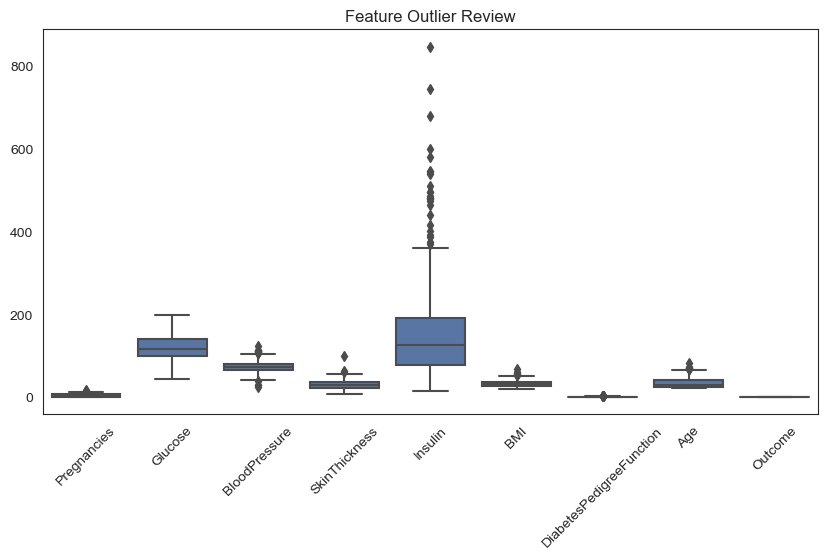

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, color=PRIMARY)
plt.xticks(rotation=45)
plt.title("Feature Outlier Review")
plt.show()

### Outlier Review Insight

The boxplots help identify unusual observations in numerical features. Outliers should be reviewed carefully because extreme values can influence model behavior.

## 10. Preparing Features and Target

In [14]:
df_clean = df_clean.fillna(df_clean.median())

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

## 11. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

## 12. Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 13. Logistic Regression — Short Review

Logistic Regression is a classification algorithm used to estimate the probability of a binary outcome.

Unlike Linear Regression, which predicts continuous values, Logistic Regression models the probability that an observation belongs to a specific class:

$$
P(y=1|x)=\frac{1}{1+e^{-(\beta_0+\beta_1x_1+\cdots+\beta_px_p)}}
$$

The predicted probability is converted into a class label using a decision threshold, commonly 0.5.

The model learns feature coefficients that describe how each input variable influences the predicted probability. Positive coefficients increase the likelihood of the positive class, while negative coefficients decrease it.

For this project, Logistic Regression was selected as an interpretable baseline because understanding feature influence is valuable in medical prediction tasks.

In this type of problem, model evaluation should not rely only on accuracy. Metrics such as recall and ROC-AUC provide additional insight into how effectively the model identifies positive cases.


## 14. Train the Model

In [17]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

## 15. Evaluation Metrics

In [18]:
evaluation = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
    "Score":[ accuracy_score(y_test,y_pred),
              precision_score(y_test,y_pred),
              recall_score(y_test,y_pred),
              f1_score(y_test,y_pred),
              roc_auc_score(y_test,y_prob)
             ]
                          })

evaluation

,Metric,Score
0,Accuracy,0.707792
1,Precision,0.600000
2,Recall,0.500000
3,F1 Score,0.545455
4,ROC-AUC,0.812963


### Evaluation Metrics Insight

Using multiple evaluation metrics provides a more complete view of classification performance. Accuracy alone may not be sufficient, especially in medical prediction problems where correctly identifying positive cases is important.

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### Classification Report Insight

Precision, recall, and F1-score provide additional details about the model's ability to correctly classify each class and balance different types of errors.

### Confusion Matrix

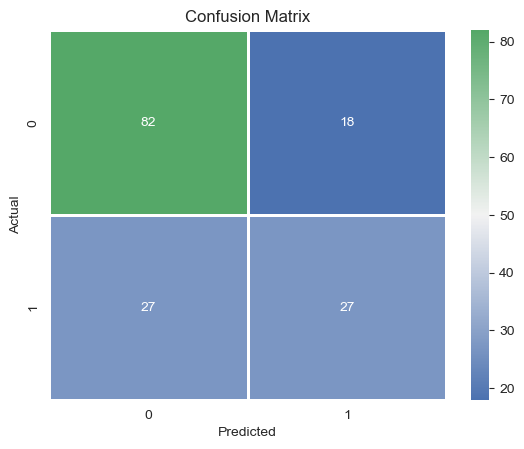

In [20]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap=correlation_cmap, linewidths=1)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Insight

The confusion matrix shows the number of correct and incorrect predictions for each class. It helps identify false negatives and false positives, which are important when evaluating medical classification models.

### ROC Curve

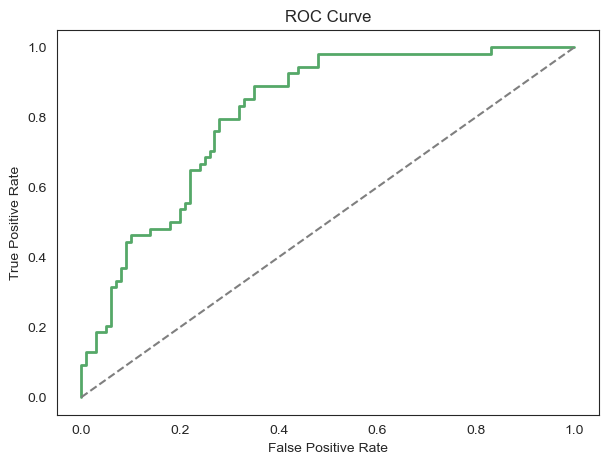

In [21]:
fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color=SECONDARY, linewidth=2)
plt.plot([0,1],[0,1],"--", color=NEUTRAL)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### ROC Curve Insight

The ROC curve illustrates the trade-off between true positive rate and false positive rate across different classification thresholds. ROC-AUC summarizes the model's ability to separate the two classes.

## 16. Model Interpretation

In [22]:
coefficients = pd.DataFrame({ "Feature": X.columns, "Coefficient": model.coef_[0]})

coefficients.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.182570
5,BMI,0.689079
0,Pregnancies,0.377217
6,DiabetesPedigreeFunction,0.233278
7,Age,0.148342
3,SkinThickness,0.027919
2,BloodPressure,-0.044355
4,Insulin,-0.066252


### Model Coefficients Insight

The coefficients show how each feature influences the predicted probability. Positive and negative values indicate the direction of influence on the diabetes prediction.

## 17. Cross-Validation

Cross-validation provides a more reliable estimate of model performance.


In [23]:
cv_scores = cross_val_score( model, scaler.fit_transform(X), y, cv=5, scoring="accuracy" )
cv_scores

array([0.75974026, 0.74675325, 0.78571429, 0.79738562, 0.77124183])

### Cross-Validation Insight

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple data splits instead of relying on a single train/test split.

## 18. Example Prediction

In [24]:
sample = X_test.iloc[[0]]

prediction = model.predict( scaler.transform(sample) )
prediction

array([1], dtype=int64)

### Example Prediction Insight

This example demonstrates how the trained model can be used on unseen data following the same preprocessing workflow applied during training.

## 19. Results

The Logistic Regression model provides an interpretable baseline for diabetes classification.


## 20. Conclusion

This project demonstrates a complete machine learning workflow for diabetes prediction:

- Data validation and quality review
- Exploratory data analysis
- Feature preparation and preprocessing
- Logistic Regression baseline modeling
- Model evaluation using multiple classification metrics
- Hyperparameter tuning with GridSearchCV
- Threshold optimization for decision improvement

The baseline Logistic Regression model provided an interpretable starting point. GridSearchCV was evaluated as a model improvement strategy; however, the tuned model did not outperform the baseline on the test set.

Further analysis showed that changing the classification threshold had a meaningful impact on model performance. Reducing the threshold to 0.3 improved recall and F1-score, allowing the model to identify more positive diabetes cases while increasing false positives.

This demonstrates that improving a machine learning solution is not limited to changing algorithms. Model evaluation strategy and decision thresholds can also play an important role depending on the objective of the problem.


## 21. Future Improvements

Potential improvements:
- Compare with Random Forest and XGBoost
- Hyperparameter tuning
- Feature selection
- Ensemble methods


## 22. Technologies & Libraries

Core concepts used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Classification Metrics
- Data Preprocessing


## 23. GitHub ↔ Kaggle

This notebook is designed as a reproducible project workflow that can be shared through GitHub and Kaggle.


## Algorithm Selection Considerations

Logistic Regression was selected as the main algorithm for this project because the focus is on understanding and implementing an interpretable classification model.

However, the best algorithm depends on the characteristics of the dataset. Factors such as:

- Dataset size
- Feature relationships
- Linear or non-linear patterns
- Feature complexity
- Class distribution

can influence model performance.

For tabular classification problems, other algorithms can also be considered:

- **Decision Tree:** useful when rule-based decisions and interpretability are important.
- **Random Forest:** can capture more complex relationships and reduce overfitting compared with a single tree.
- **Gradient Boosting / XGBoost:** often effective for structured datasets by combining multiple models.
- **Support Vector Machine (SVM):** can perform well when class boundaries are more complex.
- **K-Nearest Neighbors (KNN):** can be useful when similar observations have similar outcomes.

A complete machine learning workflow would compare multiple algorithms and select the final model based on appropriate evaluation metrics.

In this project, Logistic Regression was implemented intentionally to build a strong understanding of:

- Classification fundamentals
- Probability-based prediction
- Model coefficients
- Evaluation metrics
- Model interpretation

Future improvements can extend this baseline by comparing additional algorithms and tuning the selected models based on the project objective.

# Model Improvement Strategies

The baseline Logistic Regression model provides an interpretable starting point. 
However, machine learning projects usually continue beyond the first model by investigating how performance can be improved.

The goal is not only to increase a single metric, but to understand which changes can improve generalization and make predictions more reliable.

## Baseline Model Performance

The initial model should be treated as a reference point.

Improvement strategies can be evaluated by comparing new approaches against this baseline using:

- Recall
- Precision
- F1-score
- ROC-AUC
- Accuracy

In medical prediction problems, improving the identification of positive cases is often an important consideration.

## 1. Improve Data Preparation

Better data preparation can improve model stability.

Possible approaches:

- Review invalid values
- Handle missing values carefully
- Review outliers
- Apply appropriate scaling

A cleaner input dataset helps the model learn more meaningful patterns.

## 2. Feature Engineering

Raw features may not always represent the most informative patterns.

Potential improvements:

- Create clinically meaningful feature groups
- Add interaction features
- Transform skewed variables
- Select the most informative features

Better feature representation can improve the model's ability to separate classes.

## 3. Handling Class Imbalance

When one class is more frequent than another, the model may become biased toward the majority class.

Possible approaches:

- Use `class_weight="balanced"`
- Adjust classification threshold
- Apply resampling techniques

The objective is to improve detection of positive cases without unnecessarily increasing false alarms.

## 4. Hyperparameter Tuning

Logistic Regression performance depends on model parameters.

Important parameters include:

- Regularization strength (`C`)
- Penalty type
- Solver selection

Techniques such as Grid Search or Random Search can be used to find better configurations.

## 5. Compare Different Algorithms

Logistic Regression is an interpretable baseline.

For further improvement, other algorithms can be compared:

- Random Forest
- Gradient Boosting
- XGBoost

The final model should be selected based on appropriate evaluation metrics, not only one score.

# Model Improvement: Hyperparameter Tuning with GridSearchCV

The baseline Logistic Regression model provides a reliable starting point. 
To improve performance, hyperparameter tuning can be applied to find a better combination of model settings.

GridSearchCV evaluates multiple parameter combinations using cross-validation and selects the configuration with the best performance based on the chosen evaluation metric.

## Parameters to Tune

Important Logistic Regression parameters:

- **C**: Controls regularization strength.
- **Penalty**: Defines the type of regularization.
- **Solver**: Optimization algorithm used during training.

The goal is to find a configuration that improves generalization while avoiding overfitting.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = { "C": [0.01, 0.1, 1, 10, 100],
               "penalty": ["l1", "l2"],
               "solver": ["liblinear"]
             }

grid_search = GridSearchCV( LogisticRegression(random_state=42), param_grid, cv=5, scoring="roc_auc" )

grid_search.fit( X_train_scaled, y_train )

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [26]:
y_pred_tuned = best_model.predict(X_test_scaled)
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:,1]

tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "GridSearch Logistic Regression": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

tuned_results

,Metric,Baseline Logistic Regression,GridSearch Logistic Regression
0,Accuracy,0.707792,0.694805
1,Precision,0.600000,0.574468
2,Recall,0.500000,0.500000
3,F1 Score,0.545455,0.534653
4,ROC-AUC,0.812963,0.812778


## GridSearchCV Results Analysis

The comparison shows how hyperparameter tuning changes model performance.

The best model should not be selected only by accuracy. In medical classification problems, recall and ROC-AUC are also important because they provide insight into the model's ability to identify positive cases.

GridSearchCV provides a systematic approach to improving the baseline model while keeping the workflow reproducible.

# Threshold Optimization

Logistic Regression generates probabilities before assigning final class labels.

The default classification threshold is usually 0.5, but this value may not be optimal for every problem.

For medical prediction tasks, different thresholds can be evaluated to understand the trade-off between identifying positive cases (Recall) and avoiding false positives (Precision).

In [27]:
threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_threshold_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_threshold_pred),
        "Precision": precision_score(y_test, y_threshold_pred),
        "Recall": recall_score(y_test, y_threshold_pred),
        "F1 Score": f1_score(y_test, y_threshold_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.740260,0.597222,0.796296,0.682540
1,0.4,0.733766,0.614035,0.648148,0.630631
2,0.5,0.707792,0.600000,0.500000,0.545455
3,0.6,0.720779,0.641026,0.462963,0.537634


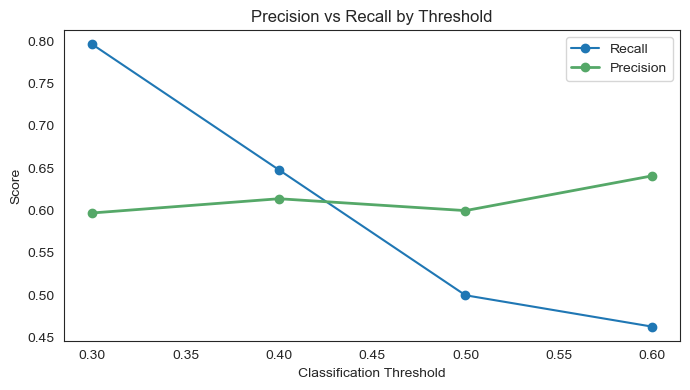

In [28]:
plt.figure(figsize=(7,4))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    color=SECONDARY,
    linewidth=2,
    label="Precision"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall by Threshold")
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Optimization Analysis

Changing the threshold changes the balance between precision and recall.

A lower threshold may increase recall by identifying more positive cases, while a higher threshold may improve precision.

The final threshold should be selected according to the objective of the prediction problem and supported by evaluation results.

## Final Threshold Comparison

After evaluating different classification thresholds, the results are compared to understand the effect on model performance.

The objective is not to maximize one metric only, but to find an appropriate balance between identifying positive cases and reducing false positives.

In [29]:
selected_thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_comparison = []

for threshold in selected_thresholds:
    y_threshold_pred = (y_prob >= threshold).astype(int)

    threshold_comparison.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_threshold_pred),
        "Precision": precision_score(y_test, y_threshold_pred),
        "Recall": recall_score(y_test, y_threshold_pred),
        "F1 Score": f1_score(y_test, y_threshold_pred)
    })

threshold_comparison_df = pd.DataFrame(threshold_comparison)

threshold_comparison_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.740260,0.597222,0.796296,0.682540
1,0.4,0.733766,0.614035,0.648148,0.630631
2,0.5,0.707792,0.600000,0.500000,0.545455
3,0.6,0.720779,0.641026,0.462963,0.537634


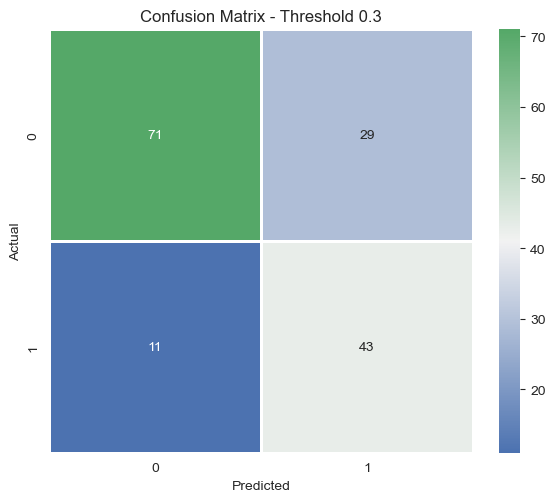

In [30]:
# Example: Confusion Matrix for the lower threshold option

chosen_threshold = 0.3

y_threshold_final = (y_prob >= chosen_threshold).astype(int)

cm_threshold = confusion_matrix(
    y_test,
    y_threshold_final
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap=correlation_cmap,
    linewidths=1,
    linecolor="white",
    square=True
)

plt.title(f"Confusion Matrix - Threshold {chosen_threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Final Threshold Analysis

The threshold comparison demonstrates that changing the decision boundary affects the balance between precision and recall.

A lower threshold increases sensitivity by identifying more positive cases, while a higher threshold improves precision by reducing false positives.

For medical prediction problems, threshold selection should be based on the practical objective of the model and the acceptable trade-off between missed cases and additional evaluations.

## Selected Decision Threshold: 0.3 (Recall-focused Evaluation)

Based on the threshold comparison, a threshold of 0.3 provides a different performance trade-off compared with the default value of 0.5.

At this threshold:

- Accuracy increased from approximately 0.71 to 0.74.
- Recall improved from 0.50 to approximately 0.80.
- F1 Score improved from approximately 0.55 to 0.68.

The main improvement is the model's ability to identify more positive diabetes cases.

## Confusion Matrix Interpretation

Using a threshold of 0.3:

- True Negative: 71
- False Positive: 29
- False Negative: 11
- True Positive: 43

Compared with the default threshold, the model detects more positive cases but also produces more false positives.

This trade-off is expected when lowering the decision threshold.

## Final Model Decision

The selected threshold should not be considered universally optimal. It depends on the objective of the prediction system.

For this medical classification task, a recall-focused approach is reasonable because missing positive cases can be more critical than performing additional follow-up evaluations for false positives.

Therefore, threshold optimization demonstrates that improving a machine learning model is not limited to changing algorithms; decision strategies and evaluation objectives also play an important role.

## What I Learned

The main lesson from this project was that improving a machine learning model is not only about achieving a higher metric value.

Building a Logistic Regression baseline provided an interpretable starting point and helped evaluate how different metrics reflect model performance. This project showed that in medical classification problems, recall, precision, and the cost of prediction errors are as important as accuracy.

GridSearchCV was useful for testing different model configurations, but the results showed that more complex tuning does not always lead to better performance. The biggest improvement came from optimizing the classification threshold and aligning the decision strategy with the goal of identifying positive cases.

This project reinforced the importance of building reproducible workflows, validating improvements with evidence, and making every modeling decision clear and explainable.